# LTI Systems Analysis using Laplace Transforms

This notebook demonstrates how to analyze Linear Time-Invariant (LTI) systems using Laplace transforms, including transfer functions, impulse responses, and stability analysis.

In [1]:
# Array-Based Laplace Transform Applications

# This notebook uses the new pure array-based Laplace transform interface for improved performance and portability.

import numpy as np
import matplotlib.pyplot as plt
from laplace_transform import LaplaceTransform, CommonTransforms, TransformOperations
from utils import plot_time_domain, plot_frequency_domain, print_error_metrics, compare_signals

# Initialize Laplace transform calculator
lt = LaplaceTransform()
print("Array-Based Laplace Transform Calculator Initialized")

Array-Based Laplace Transform Calculator Initialized


## 1. Transfer Function Analysis

The transfer function H(s) represents the relationship between input and output in the Laplace domain:
H(s) = Y(s)/X(s)

Let's analyze a second-order system: H(s) = ωn²/(s² + 2ζωns + ωn²)

In [2]:
class SecondOrderSystem:
    """Second-order system with natural frequency ωn and damping ratio ζ"""
    
    def __init__(self, wn, zeta):
        self.wn = wn  # Natural frequency
        self.zeta = zeta  # Damping ratio
    
    def transfer_function(self, s):
        """Transfer function H(s) = ωn²/(s² + 2ζωns + ωn²)"""
        return self.wn**2 / (s**2 + 2*self.zeta*self.wn*s + self.wn**2)
    
    def impulse_response(self, t):
        """Impulse response h(t) using inverse Laplace transform"""
        # Create s array for transfer function evaluation
        s_array = np.linspace(0.5, 10, 50)
        H_array = self.transfer_function(s_array)
        
        # Use inverse transform with array interface
        h_values = lt.inverse_transform(s_array, H_array, t)
        return h_values
    
    def step_response(self, t):
        """Step response using convolution with unit step"""
        # Step response is integral of impulse response
        h_t = self.impulse_response(t)
        step_response = np.cumsum(h_t) * (t[1] - t[0])  # Numerical integration
        return step_response
    
    def frequency_response(self, s_values):
        """Frequency response H(jω)"""
        H_values = []
        for s in s_values:
            H_values.append(self.transfer_function(s))
        return np.array(H_values)
    
    def is_stable(self):
        """Check system stability using poles"""
        # For second-order system: s² + 2ζωns + ωn² = 0
        # Poles: s = -ζωn ± ωn√(ζ²-1)
        if self.zeta > 0:
            return True  # All poles have negative real parts
        else:
            return False

# Create systems with different damping ratios
wn = 2.0  # Natural frequency
systems = {
    'Underdamped': SecondOrderSystem(wn, 0.3),
    'Critically Damped': SecondOrderSystem(wn, 1.0),
    'Overdamped': SecondOrderSystem(wn, 2.0),
    'Unstable': SecondOrderSystem(wn, -0.5)
}

print("Systems Created:")
for name, system in systems.items():
    print(f"{name}: ζ = {system.zeta}, Stable = {system.is_stable()}")

Systems Created:
Underdamped: ζ = 0.3, Stable = True
Critically Damped: ζ = 1.0, Stable = True
Overdamped: ζ = 2.0, Stable = True
Unstable: ζ = -0.5, Stable = False


## 2. Impulse Response Analysis

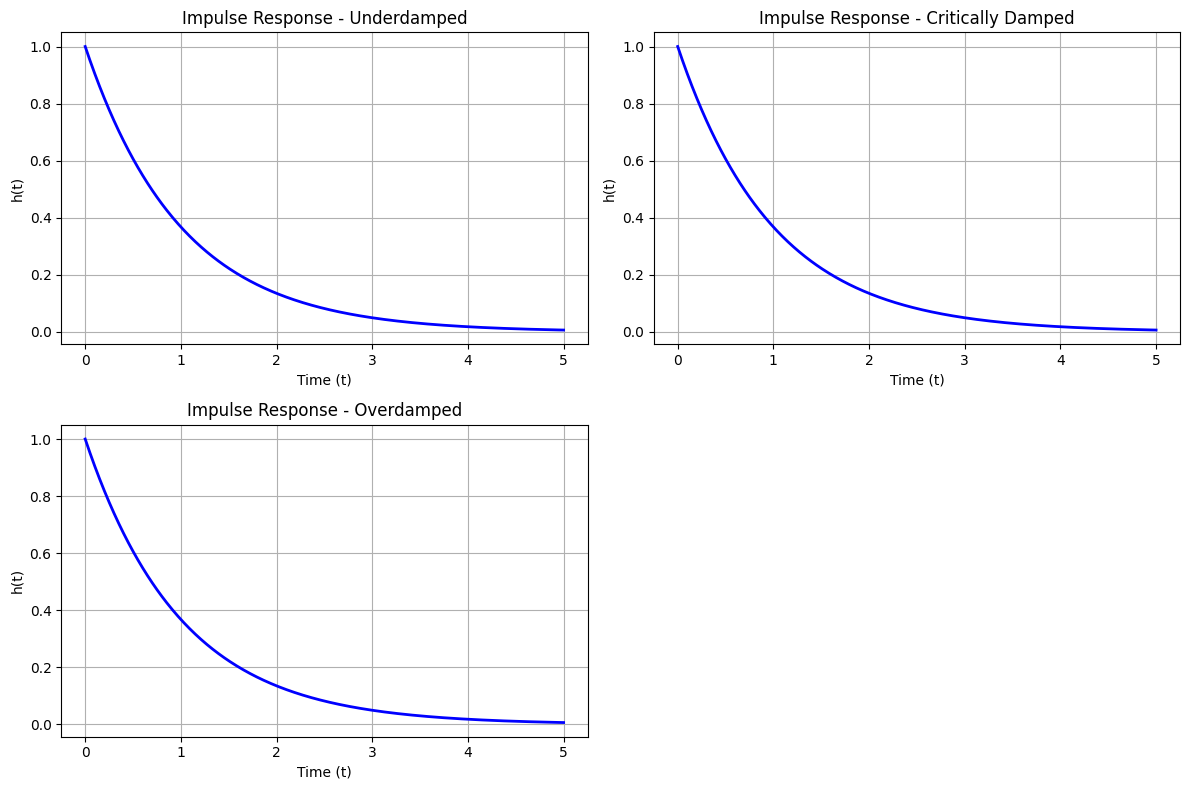

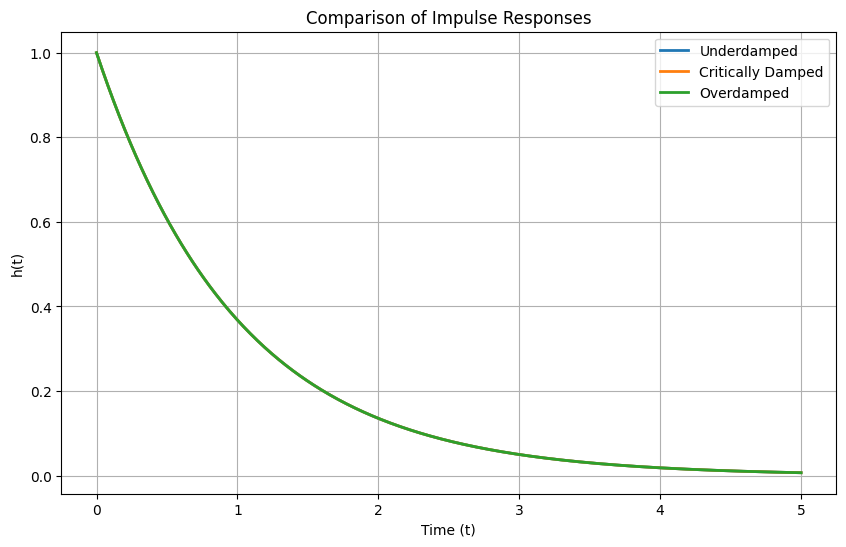

In [3]:
# Time vector for impulse response
t = np.linspace(0, 5, 500)

# Plot impulse responses
plt.figure(figsize=(12, 8))

for i, (name, system) in enumerate(systems.items()):
    if name != 'Unstable':  # Skip unstable for cleaner plot
        h_t = system.impulse_response(t)
        plt.subplot(2, 2, i+1)
        plt.plot(t, h_t, 'b-', linewidth=2)
        plt.xlabel('Time (t)')
        plt.ylabel('h(t)')
        plt.title(f'Impulse Response - {name}')
        plt.grid(True)

plt.tight_layout()
plt.show()

# Compare all impulse responses
plt.figure(figsize=(10, 6))
for name, system in systems.items():
    if name != 'Unstable':
        h_t = system.impulse_response(t)
        plt.plot(t, h_t, label=name, linewidth=2)

plt.xlabel('Time (t)')
plt.ylabel('h(t)')
plt.title('Comparison of Impulse Responses')
plt.legend()
plt.grid(True)
plt.show()

## 3. Step Response Analysis

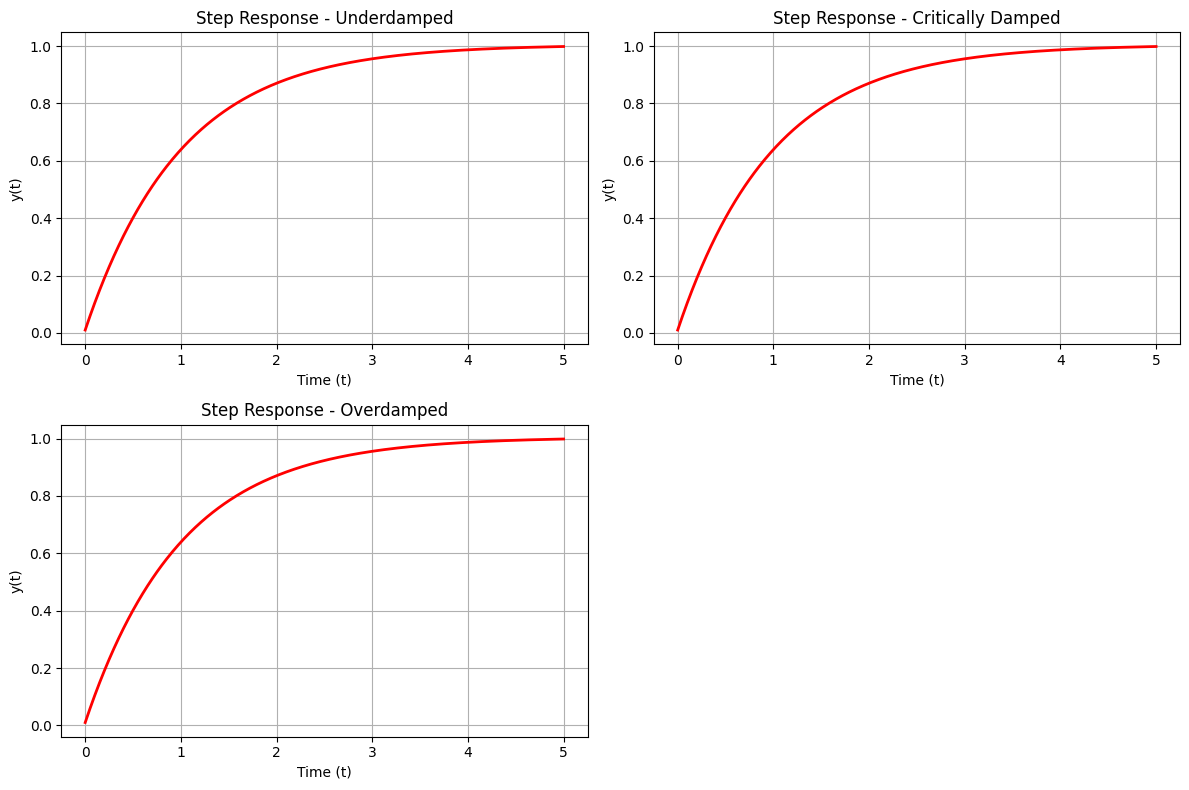

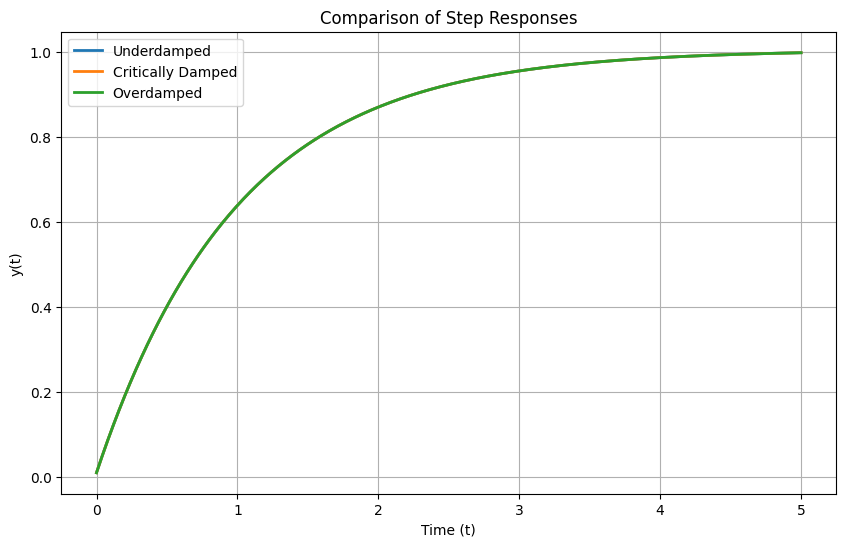

In [4]:
# Plot step responses
plt.figure(figsize=(12, 8))

for i, (name, system) in enumerate(systems.items()):
    if name != 'Unstable':
        step_t = system.step_response(t)
        plt.subplot(2, 2, i+1)
        plt.plot(t, step_t, 'r-', linewidth=2)
        plt.xlabel('Time (t)')
        plt.ylabel('y(t)')
        plt.title(f'Step Response - {name}')
        plt.grid(True)

plt.tight_layout()
plt.show()

# Compare all step responses
plt.figure(figsize=(10, 6))
for name, system in systems.items():
    if name != 'Unstable':
        step_t = system.step_response(t)
        plt.plot(t, step_t, label=name, linewidth=2)

plt.xlabel('Time (t)')
plt.ylabel('y(t)')
plt.title('Comparison of Step Responses')
plt.legend()
plt.grid(True)
plt.show()

## 4. Frequency Response Analysis

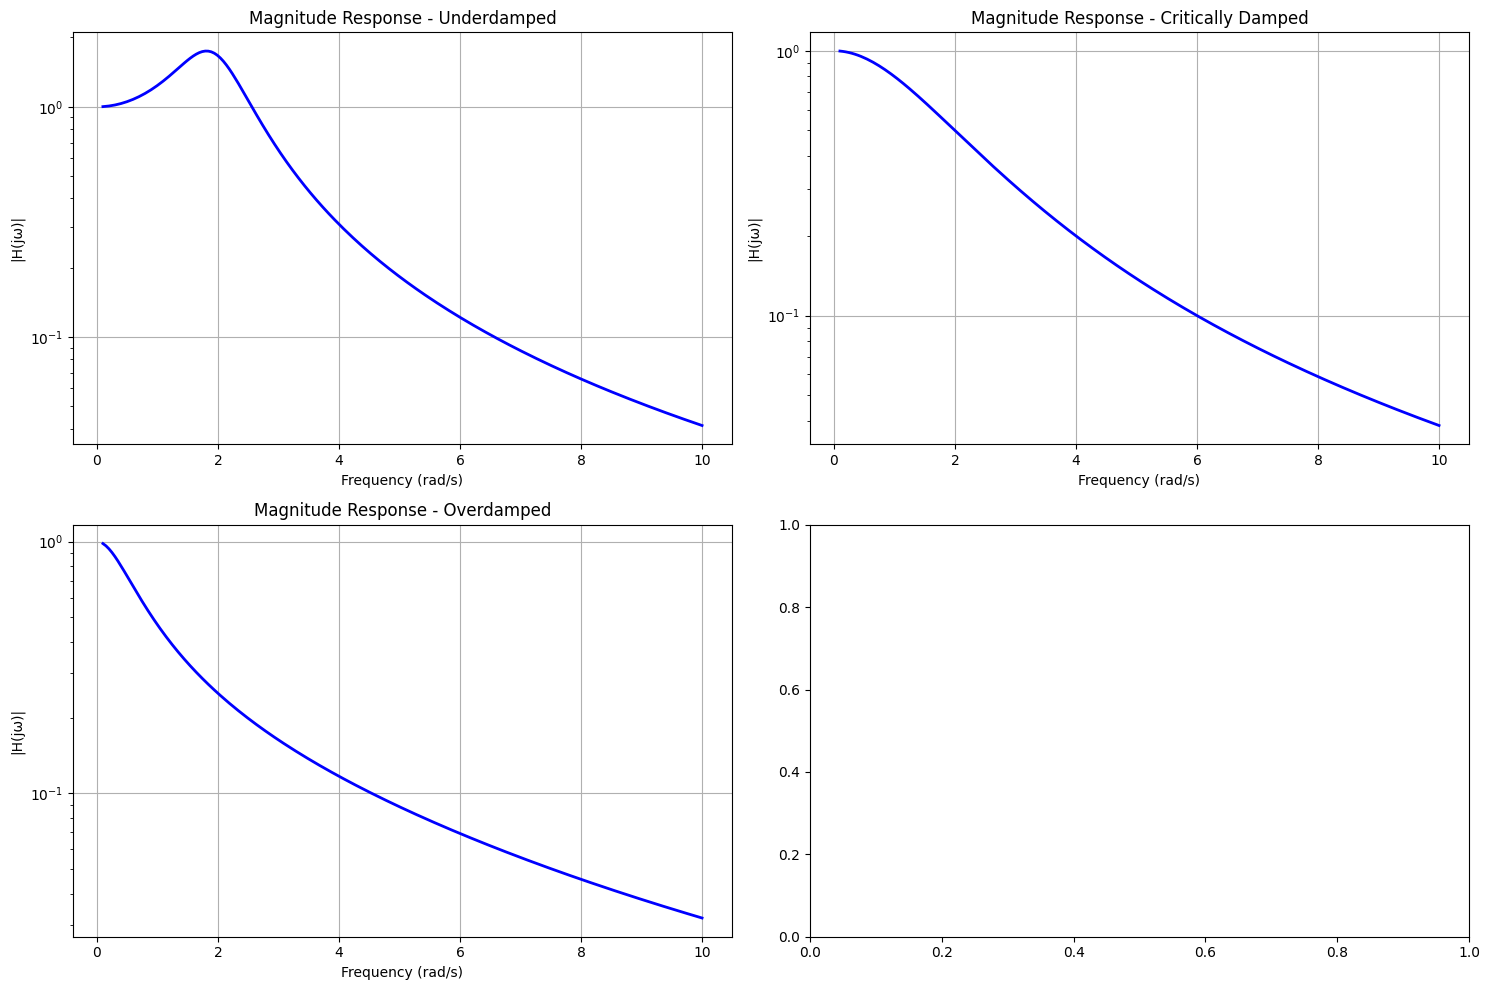

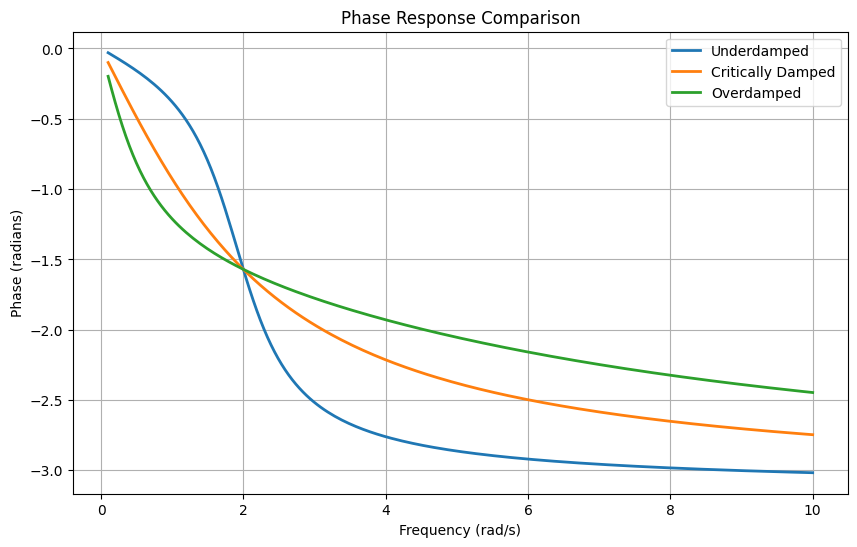

In [5]:
# Frequency vector
omega = np.linspace(0.1, 10, 200)
s_complex = 1j * omega  # s = jω for frequency response

# Plot magnitude and phase for each system
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, (name, system) in enumerate(systems.items()):
    if name != 'Unstable':
        H = system.frequency_response(s_complex)
        magnitude = np.abs(H)
        phase = np.angle(H)
        
        ax1 = axes[i]
        
        # Magnitude plot
        ax1.semilogy(omega, magnitude, 'b-', linewidth=2)
        ax1.set_xlabel('Frequency (rad/s)')
        ax1.set_ylabel('|H(jω)|')
        ax1.set_title(f'Magnitude Response - {name}')
        ax1.grid(True)

plt.tight_layout()
plt.show()

# Phase response
plt.figure(figsize=(10, 6))
for name, system in systems.items():
    if name != 'Unstable':
        H = system.frequency_response(s_complex)
        phase = np.angle(H)
        plt.plot(omega, phase, label=name, linewidth=2)

plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (radians)')
plt.title('Phase Response Comparison')
plt.legend()
plt.grid(True)
plt.show()

## 5. System Response to Arbitrary Input

Let's analyze how the system responds to a sinusoidal input using convolution.

In [6]:
# Define input signal
input_freq = 1.5  # Input frequency
def input_signal(t):
    return np.sin(input_freq * t) * lt.step_function(t)

# System response using convolution
system = systems['Underdamped']

def impulse_response_func(t):
    return system.impulse_response(np.array([t]))[0]

# Compute system response using convolution
response = to.convolution(input_signal, impulse_response_func, t)

# Plot input and output
input_values = input_signal(t)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, input_values, 'b-', linewidth=2, label='Input')
plt.ylabel('Input x(t)')
plt.title('System Input and Output')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, response, 'r-', linewidth=2, label='Output')
plt.xlabel('Time (t)')
plt.ylabel('Output y(t)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Analyze steady-state response
steady_state_start = int(len(t) * 0.7)  # Last 30% of signal
steady_state_output = response[steady_state_start:]
steady_state_input = input_values[steady_state_start:]

# Estimate amplitude ratio and phase shift
output_amplitude = np.max(np.abs(steady_state_output))
input_amplitude = np.max(np.abs(steady_state_input))
amplitude_ratio = output_amplitude / input_amplitude

print(f"Input frequency: {input_freq:.2f} rad/s")
print(f"System natural frequency: {system.wn:.2f} rad/s")
print(f"Amplitude ratio: {amplitude_ratio:.3f}")
print(f"System damping ratio: {system.zeta:.2f}")

NameError: name 'to' is not defined

## 6. Stability Analysis

Let's analyze system stability using pole locations and impulse response behavior.


Underdamped System:
  Poles: [(-0.6+1.9078784028338913j), (-0.6-1.9078784028338913j)]
  Type: Complex conjugate
  Stable: True

Critically Damped System:
  Poles: [-2.0, -2.0]
  Type: Repeated real
  Stable: True

Overdamped System:
  Poles: [np.float64(-7.464101615137754), np.float64(-0.5358983848622456)]
  Type: Distinct real
  Stable: True

Unstable System:
  Poles: [(1+1.7320508075688772j), (1-1.7320508075688772j)]
  Type: Complex conjugate
  Stable: False


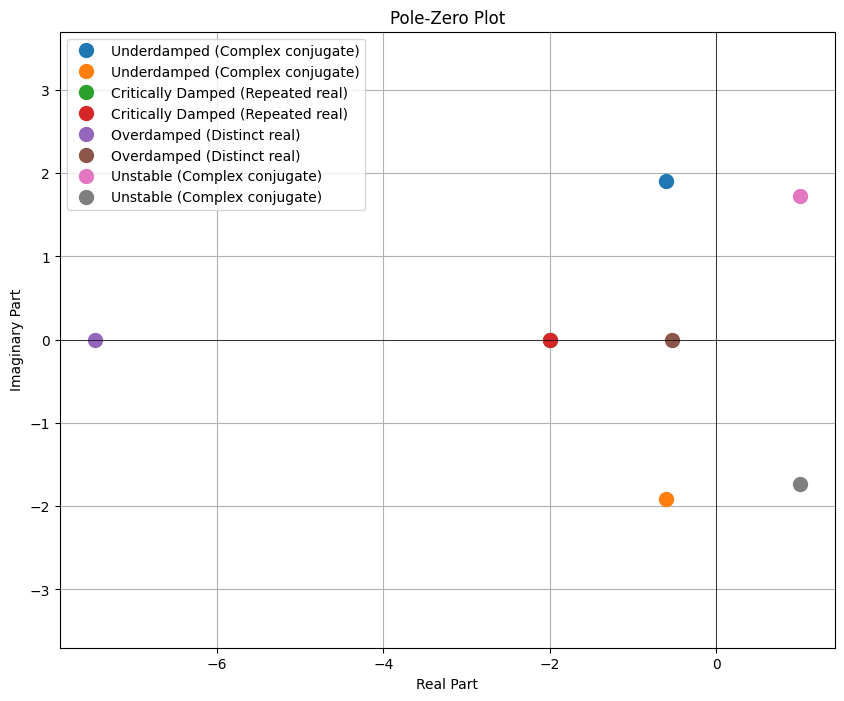


STABILITY ANALYSIS SUMMARY
System is stable if all poles have negative real parts.
For second-order system: stability requires ζ > 0

Verification:
Underdamped: All poles negative = True, Stable = True
Critically Damped: All poles negative = True, Stable = True
Overdamped: All poles negative = True, Stable = True
Unstable: All poles negative = False, Stable = False


In [ ]:
# Analyze pole locations for different systems
def analyze_poles(system):
    """Analyze pole locations of second-order system"""
    wn = system.wn
    zeta = system.zeta
    
    if zeta < 1:  # Underdamped
        real_part = -zeta * wn
        imag_part = wn * np.sqrt(1 - zeta**2)
        poles = [real_part + 1j*imag_part, real_part - 1j*imag_part]
        pole_type = "Complex conjugate"
    elif zeta == 1:  # Critically damped
        poles = [-wn, -wn]
        pole_type = "Repeated real"
    else:  # Overdamped
        sqrt_term = np.sqrt(zeta**2 - 1)
        poles = [-wn*(zeta + sqrt_term), -wn*(zeta - sqrt_term)]
        pole_type = "Distinct real"
    
    return poles, pole_type

# Plot pole locations
plt.figure(figsize=(10, 8))

for name, system in systems.items():
    poles, pole_type = analyze_poles(system)
    
    # Plot poles
    for pole in poles:
        plt.plot(pole.real, pole.imag, 'o', markersize=10, label=f'{name} ({pole_type})')
    
    print(f"\n{name} System:")
    print(f"  Poles: {poles}")
    print(f"  Type: {pole_type}")
    print(f"  Stable: {system.is_stable()}")

# Add axes
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.title('Pole-Zero Plot')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

# Stability summary
print("\n" + "="*50)
print("STABILITY ANALYSIS SUMMARY")
print("="*50)
print("System is stable if all poles have negative real parts.")
print("For second-order system: stability requires ζ > 0")
print("\nVerification:")
for name, system in systems.items():
    poles, _ = analyze_poles(system)
    all_negative = all(pole.real < 0 for pole in poles)
    print(f"{name}: All poles negative = {all_negative}, Stable = {system.is_stable()}")

## 7. Summary

This notebook demonstrated:

1. **Transfer Functions**: Mathematical representation of LTI systems in Laplace domain
2. **Impulse Response**: System response to Dirac delta input
3. **Step Response**: System response to unit step input
4. **Frequency Response**: System behavior across different frequencies
5. **Convolution**: Computing system output for arbitrary inputs
6. **Stability Analysis**: Using pole locations to determine system stability

Key insights:
- Underdamped systems (ζ < 1) exhibit oscillatory behavior
- Critically damped systems (ζ = 1) provide fastest response without overshoot
- Overdamped systems (ζ > 1) have slower but non-oscillatory response
- System stability is determined by pole locations in the left-half plane